# Evaluating Trained FM Models' Performance

In [14]:
import os
import sys

from corner import corner

sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding, LightCurveMLP
from src.flow_matching.transformer import TransformerGuidedField
from src.helpers import record_every, plot_posterior_samples

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import torch
import yaml

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device, build_mlp, find_run_dir

device = choose_device()

In [15]:
MODELS = {
    "MLPGuidedVectorField": MLPGuidedVectorField,
    "TransformerGuidedField":TransformerGuidedField
}

TIME_ENCODERS = {
    "LightCurveThinner": LightCurveThinner,
    "FRBLightCurveCNN": FRBLightCurveCNN,
    "LightCurveMLP":LightCurveMLP
}

TAU_ENCODERS = {
    True : fourier_embedding,
    False : None 
}

THETA_ENCODERS = {
    # True : lambda theta_dim : build_mlp([2] + [2 * 4, 2 * 8] + [theta_dim]),
    True : lambda theta_dim : build_mlp([1] + [1 * 8, 1 * 32] + [theta_dim]),
    False : None
}

In [16]:
# fill in desired job_id or directory name 
job_id = "12987797" #False
run_dir = None
save_dir = "../checkpoints/"

In [17]:
# loading the model (via run_id, or path)
run_dir = find_run_dir(job_id, save_dir) if job_id else os.path.join(save_dir, run_dir)

checkpoint_path = os.path.join(run_dir, 'training_checkpoint.pth')
config_path     = os.path.join(run_dir, 'config.yaml')

In [18]:
# create empty model from config
def empty_model_from_config(path):
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
    
    model_name = config["model"]["name"]
    model_class = MODELS[model_name]
    
    kwargs = config["model"]["init_params"]

    time_encoder = False if not config["time_seq_encoder"] else config["time_seq_encoder"]["name"] 

    if time_encoder:
        t_encoder_kwargs = config["time_seq_encoder"]["init_params"]


    kwargs['time_seq_encoder']  = None if not time_encoder else TIME_ENCODERS[time_encoder](**t_encoder_kwargs)
    kwargs['tau_encoder']   = TAU_ENCODERS[config["tau_encoder"]]
    kwargs['theta_encoder'] = THETA_ENCODERS[config["theta_encoder"]]
    
    return model_class(**kwargs)

vector_field = empty_model_from_config(config_path)

/home/nvandermeulen/miniconda3/envs/FRB/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [48]:
# load trained model 
print(checkpoint_path)
checkpoint = torch.load(checkpoint_path, weights_only=False)

# Load 'normal' or EMA version 
ema = True
if ema:
    EMA_checkpoint_path = os.path.join(run_dir, "EMA_checkpoint.pth")
    state_dict = torch.load(EMA_checkpoint_path, weights_only=False)
    vector_field.load_state_dict(state_dict) 
else:
    vector_field.load_state_dict(checkpoint["model_state_dict"])

vector_field.eval()
vector_field.to(device)

losses = checkpoint["losses"]

../checkpoints/12987797_run_06_07_1516/training_checkpoint.pth


# Loss

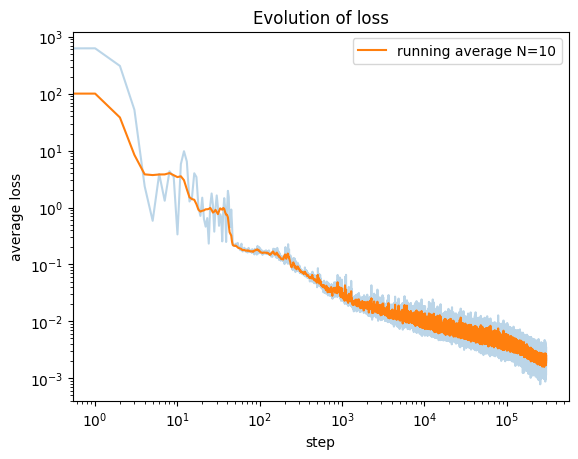

In [36]:
plot_loss(losses, window_size=10)

# Example posterior

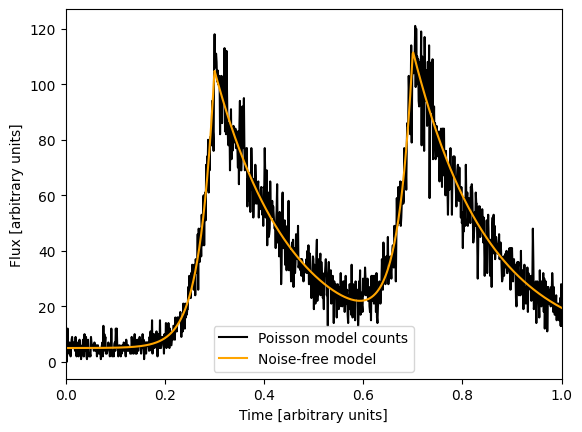

In [73]:
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 100.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.3, 0.7] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    "time": time,
    "ncomp": N,
    "burstparams":burstparams,
    "ybkg":ybkg
}

# generate one instance of simulated data to guide prior samples with
model = Model(**modelparams)
simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst() 
simulator.plot_burst()

100%|██████████| 199/199 [00:04<00:00, 45.56it/s]


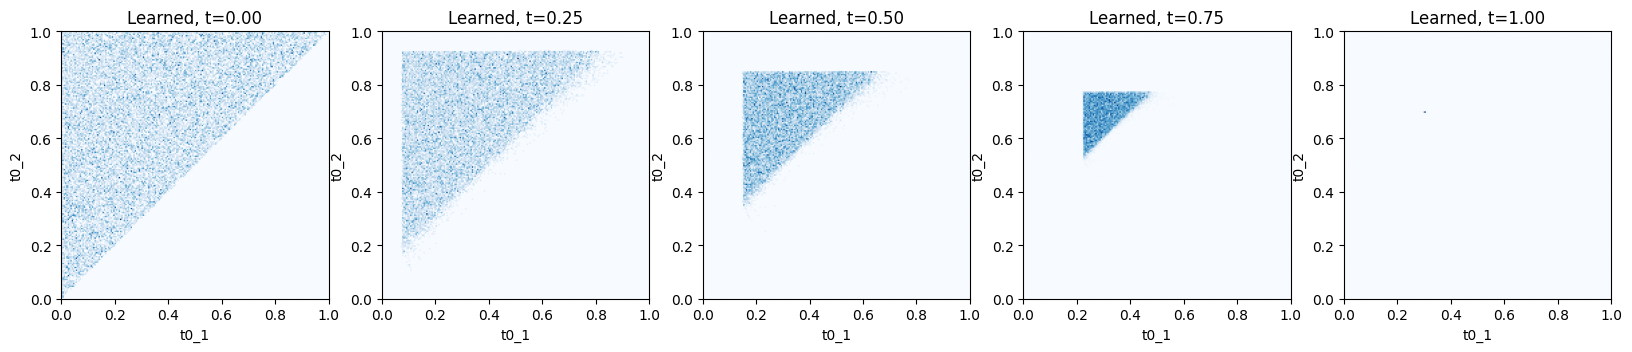

In [74]:
num_samples = 25000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# TODO: maybe do this in batches
# use same data point for conditioning all prior samples
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(num_samples, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 200
ts = torch.linspace(0, 1, nts).to(device)
# ts_2 = torch.linspace(0.90, 1, nts - 100).to(device)
# ts = torch.cat([ts, ts_2])

path = GuidedLinearProbabilityPath(
        p_simple=Prior(),
        p_data=Posterior()
    )

# simulate ODE starting from x0
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(nts, nts // (num_marginals - 1))
xts_snapshots = xts[:, record_every_idxs, :]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts_snapshots, ts, record_every_idxs, num_marginals)

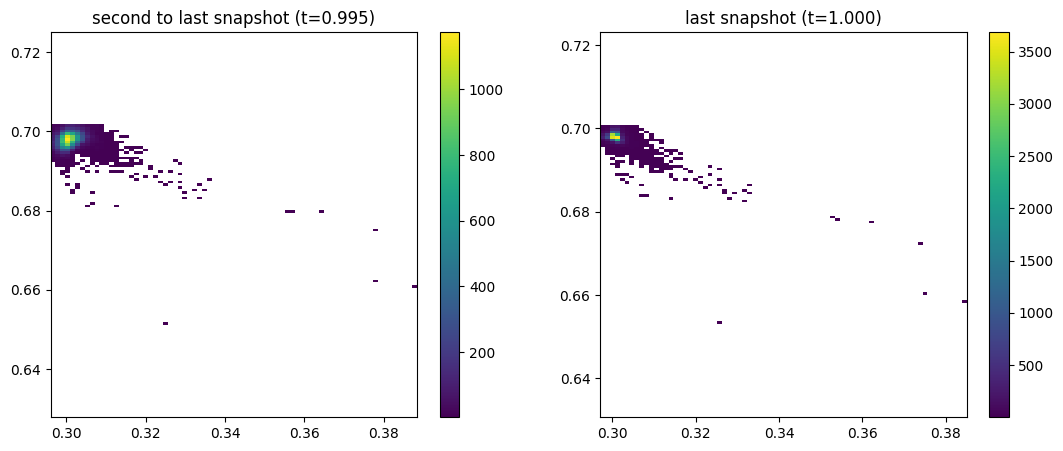

In [75]:
import matplotlib.pyplot as plt

final_snapshot = xts[:, -1, :].cpu()
penultimate_snapshot = xts[:, -2, :].cpu()
plt.figure(figsize=(13, 5))

plt.subplot(121)
plt.title(f'second to last snapshot (t={ts[-2]:.3f})')
plt.hist2d(penultimate_snapshot[:,0], penultimate_snapshot[:,1], bins=75, cmin=1)
plt.colorbar()
plt.xlim(0.290, 0.315)
plt.ylim(0.68, 0.71)
plt.axis('equal')

plt.subplot(122)
plt.title(f'last snapshot (t={ts[-1]:.3f})')
plt.hist2d(final_snapshot[:,0], final_snapshot[:,1], bins=75, cmin=1)
plt.colorbar()
plt.xlim(0.290, 0.315)
plt.ylim(0.68, 0.71)
plt.axis('equal')
plt.show()

torch.Size([1000, 2]) torch.Size([1000, 1]) torch.Size([1000, 1000])


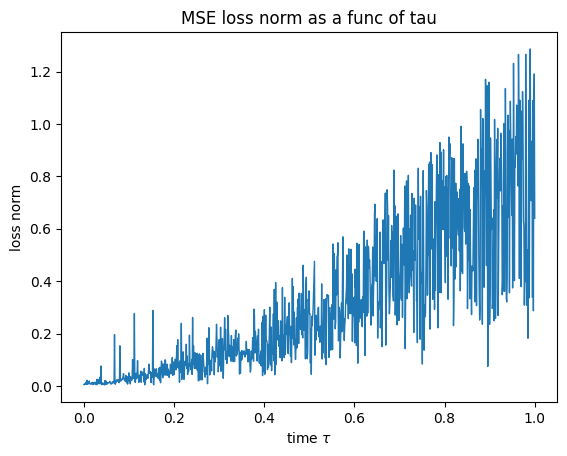

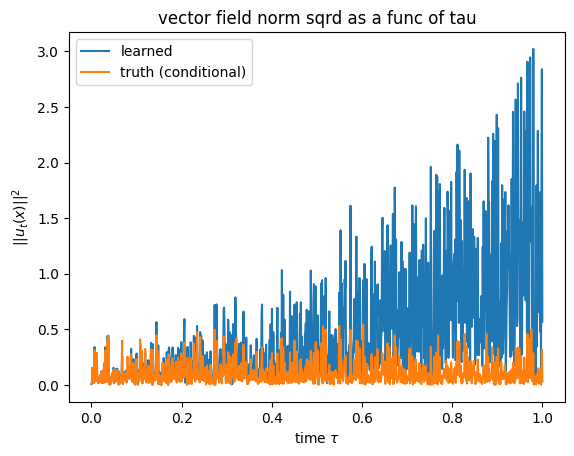

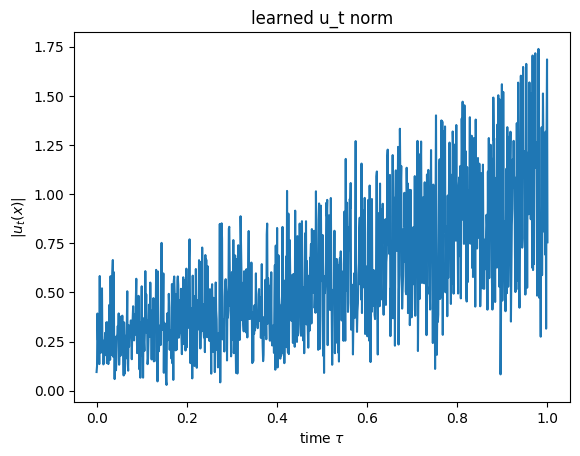

In [76]:
# plot loss over time
samples = 1000
ts_ = torch.linspace(0.0, 1.0, samples).to(device).view(-1, 1)
x0_ = path.p_simple.sample(samples).to(device)
simulations_ = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(samples, 1)
target_ = torch.tensor([[0.3, 0.7]], device=device).repeat((samples, 1))

print(x0_.shape, ts_.shape, simulations_.shape)
differences_ = (
            vector_field(x0_, ts_, simulations_)
            - path.conditional_vector_field(x0_, target_)
            ) # shape batch_size, ndim

losses_ = differences_.norm(dim=1) 
plt.title("MSE loss norm as a func of tau")
plt.plot(ts_.cpu().detach().numpy(), losses_.cpu().detach().numpy(), '-', linewidth=1)
plt.xlabel("time $\\tau$")
plt.ylabel('loss norm')
# plt.yscale('log')

plt.show()

plt.title("vector field norm sqrd as a func of tau")
plt.plot(ts_.cpu().detach().numpy(), torch.sum(vector_field(x0_, ts_, simulations_) ** 2, dim = 1).cpu().detach().numpy(),
label="learned")
plt.ylabel("$||u_t(x)||^2$")
plt.xlabel("time $\\tau$")

plt.plot(ts_.cpu().detach().numpy(), torch.sum(
    path.conditional_vector_field(x0_, target_) ** 2,
    dim = 1 # sum column wise
).cpu().detach().numpy(), label="truth (conditional)")
plt.legend()
plt.show()
# plt.yscale('log')

plt.title('learned u_t norm')
plt.plot(ts_.cpu().detach().numpy(),
    vector_field(x0_, ts_, simulations_).norm(dim=1).cpu().detach().numpy())
plt.ylabel("$|u_t(x)|$")
plt.xlabel("time $\\tau$")
plt.show()

In [77]:
nts_test = 6
x0_test = path.p_simple.sample(nts_test - 1).to(device)
x0_test = torch.cat((x0_test, torch.tensor([[0.3, 0.7]], device=device)))

In [78]:
ts_test = torch.linspace(0.95, 1.0, nts_test).to(device)
simulations_test = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(nts_test, 1)
ts_test = ts_test.view(-1, 1)

print(x0_test, ts_test)
target = torch.tensor([[0.3, 0.7]], device=device).repeat((nts_test, 1))
print("truth:", path.conditional_vector_field(x0_test, target))
print("learned:", vector_field(x0_test, ts_test, simulations_test))
differences = (
            vector_field(x0_test, ts_test, simulations_test)
            - path.conditional_vector_field(x0_test, target)
            ) # shape batch_size, ndim

losses = torch.sum(
    differences ** 2,
    dim = 1 # sum column wise
)
total_loss = torch.sum(losses)

average =  total_loss / nts_test
print(average)
if torch.isnan(average):
    print("lol")

tensor([[0.3604, 0.4515],
        [0.4724, 0.5806],
        [0.3994, 0.9527],
        [0.1764, 0.2128],
        [0.0543, 0.6575],
        [0.3000, 0.7000]], device='cuda:0') tensor([[0.9500],
        [0.9600],
        [0.9700],
        [0.9800],
        [0.9900],
        [1.0000]], device='cuda:0')
truth: tensor([[-6.0408e-02,  2.4856e-01],
        [-1.7236e-01,  1.1942e-01],
        [-9.9389e-02, -2.5259e-01],
        [ 1.2357e-01,  4.8720e-01],
        [ 2.4567e-01,  4.2530e-02],
        [ 3.0011e-05,  7.0035e-05]], device='cuda:0')
learned: tensor([[-0.3260,  0.1450],
        [-0.8019, -0.5793],
        [-0.8779, -0.3768],
        [ 0.8193,  1.0833],
        [ 0.6949,  0.3423],
        [-0.0252,  0.0159]], device='cuda:0', grad_fn=<ViewBackward0>)
tensor(0.4532, device='cuda:0', grad_fn=<DivBackward0>)


In [79]:
animate = False

if animate:
    fig, ax = plt.subplots(figsize=(7,7))

    # histogram bin range
    bins = 100
    x_edges = np.linspace(0.2, 0.4, bins + 1)
    y_edges = np.linspace(0.6, 0.8, bins + 1)

    # initial histogram
    xts = xts.cpu()
    hist, xedges, yedges, img = ax.hist2d(xts[:, 0, 0], xts[:, 0, 1], bins=[x_edges, y_edges], cmin=1)
    # plt.colorbar(img, ax=ax)
    # ax.set_title('index = 0')

    def update(frame):
        ax.clear()  
        hist, xedges, yedges, img = ax.hist2d(xts[:, frame, 0], xts[:, frame, 1],
                                            bins=100, 
                                            cmin=1)
        ax.set_title(f'timestep = {frame}')
        ax.set_xlim(x_edges[0], x_edges[-1])
        ax.set_ylim(y_edges[0], y_edges[-1])
        ax.plot(true_t0[0], true_t0[1], 'ro', markersize=4)
        
        # plt.colorbar(img, ax=ax)
        return img,

    timesteps = np.arange(900, 1000, 2)
    ani = animation.FuncAnimation(fig, update, frames=timesteps,
                                interval=200, blit=False)
    ani.save('animation2.gif')
    plt.show()

torch.Size([25000, 2])


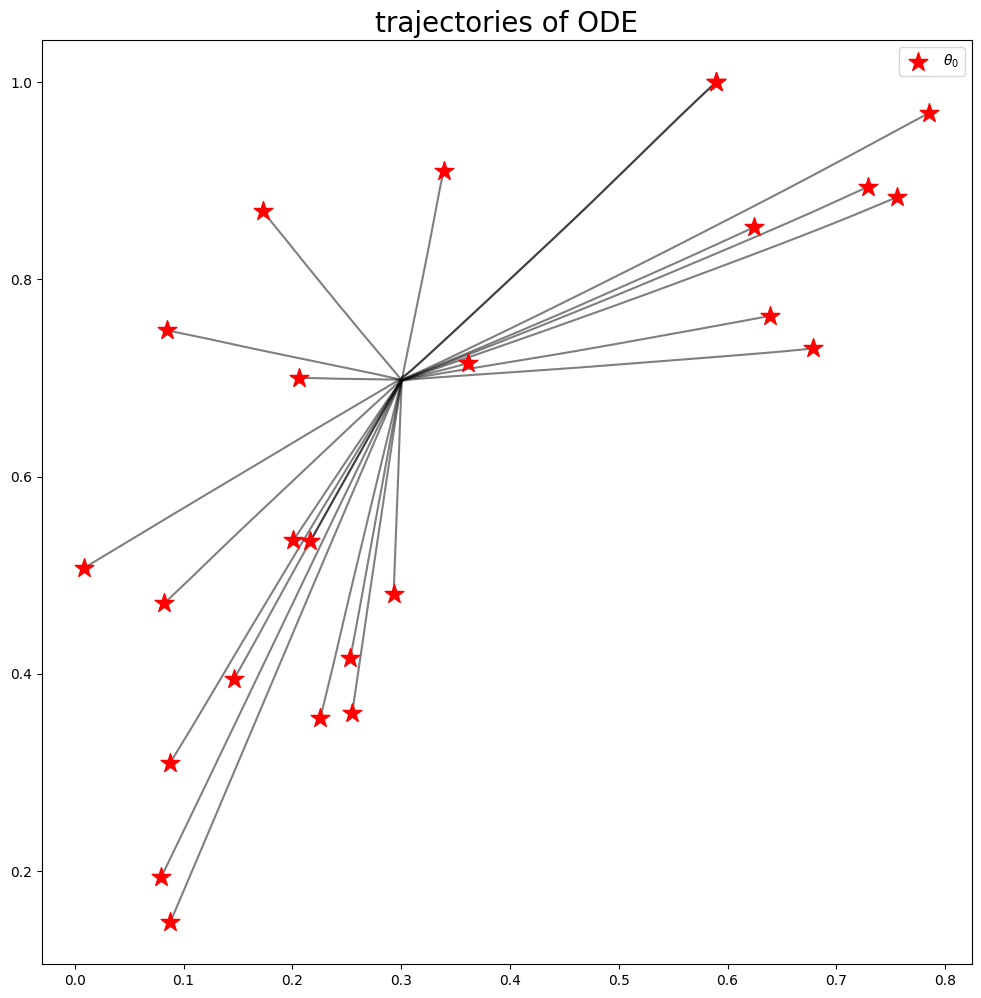

In [89]:
fig, axes = plt.subplots(1,1, figsize=(12, 12))
ax = axes
ax.set_title('trajectories of ODE', fontsize=20)
# ax.scatter(x0[:,0].cpu(), x0[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z

x_bounds=(0,1)
y_bounds=(0,1)

# plot N random trajctories
import random
N_traj = 25
traj = [random.choice(range(num_samples)) for i in range(N_traj)]
print(x0.shape)
ax.scatter(x0[traj,0].detach().cpu(), x0[traj,1].detach().cpu(), marker='*', color='red', s=200, label='$\\theta_0$',zorder=20) # Plot z

for traj_idx in traj:
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')
ax.legend(loc='upper right', markerscale=1)
plt.show()

# corner plot

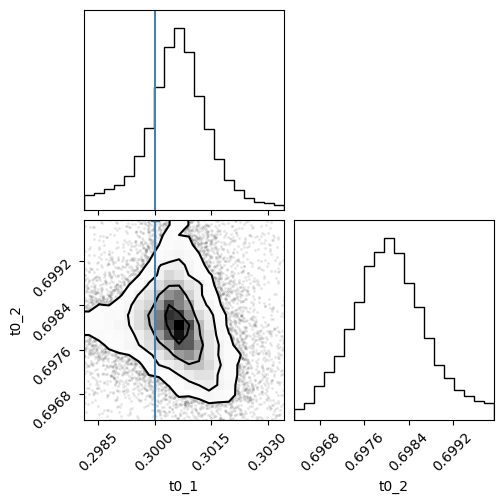

In [90]:
fig = corner(final_snapshot.cpu().numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0), range=[0.95,0.95])

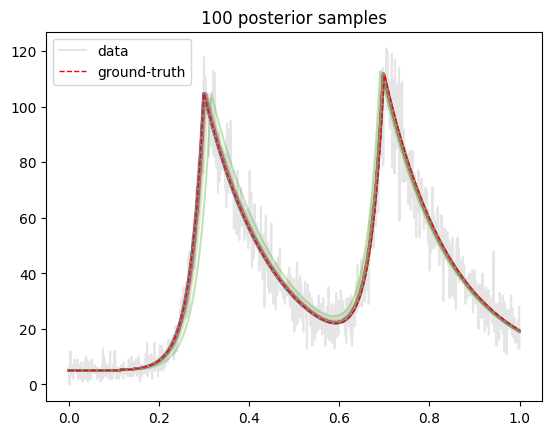

In [91]:
plot_posterior_samples(100, x_counts, final_snapshot.cpu().numpy(), ["t0"], modelparams)
true_flux = model.get_flux()

plt.plot(np.linspace(0, 1, len(true_flux)), true_flux, 'r--', linewidth=1, label="ground-truth")
plt.legend()

# PP-plot

In [18]:
# cell for PP-plot